In [1]:
import os
import cv2
from tensorflow.keras.metrics import MeanIoU
from sklearn.preprocessing import MinMaxScaler,StandardScaler
import numpy as np
import tensorflow as tf

In [11]:
root = "/kaggle/input/datasets/humansintheloop/semantic-segmentation-of-aerial-imagery/Semantic segmentation dataset/"

IMG_SIZE=256
NUM_CLASSES=6
BATCH_SIZE=1

VAL_SPLIT = 0.2

COLOR_MAP = tf.constant([
    [60, 16, 152],    # 0 Building
    [132, 41, 246],   # 1 Land
    [110, 193, 228],  # 2 Road
    [254, 221, 58],   # 3 Vegetation
    [226, 169, 41],   # 4 Water
    [155, 155, 155],  # 5 Unlabeled
], dtype=tf.uint8)

def rgb_to_class(mask_rgb):
    # mask_rgb: (H, W, 3) uint8
    mask_rgb = tf.expand_dims(mask_rgb, axis=-2)          # (H, W, 1, 3)
    colors = tf.reshape(COLOR_MAP, (1, 1, NUM_CLASSES, 3))  # (1, 1, 6, 3)
    matches = tf.reduce_all(tf.equal(mask_rgb, colors), axis=-1)  # (H, W, 6) bool
    class_id = tf.argmax(tf.cast(matches, tf.int32), axis=-1)# (H, W)
    return tf.cast(class_id, tf.int32)

def load_data(img_path):
    img=tf.io.read_file(img_path)
    img=tf.image.decode_jpeg(img,channels=3)
    img=tf.image.resize(img,(IMG_SIZE,IMG_SIZE))
    img=img/255.0
    
    mask_path=tf.strings.regex_replace(img_path,"images","masks")
    mask_path=tf.strings.regex_replace(mask_path,".jpg",".png")
    mask=tf.io.read_file(mask_path)
    mask=tf.image.decode_png(mask,channels=3)
    mask=tf.image.resize(mask,(IMG_SIZE,IMG_SIZE),method='nearest')
    mask = tf.cast(mask, tf.uint8)

    mask = rgb_to_class(mask)                             # (H, W) 类别索引 0~5
    mask = tf.cast(mask, tf.int32)
    return img, mask

img_paths=tf.data.Dataset.list_files(
    root+'*/images/*.jpg',
    shuffle=True,
    seed=42  
)
dataset=img_paths.map(load_data)
dataset=dataset.batch(4).prefetch(tf.data.AUTOTUNE)

total_count = tf.data.experimental.cardinality(img_paths).numpy()
val_count = int(total_count * VAL_SPLIT)
train_count = total_count - val_count

print(f"总样本数: {total_count}, 训练集: {train_count}, 验证集: {val_count}")

val_paths = img_paths.take(val_count)
train_paths = img_paths.skip(val_count)

train_dataset = (
    train_paths
    .map(load_data, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(buffer_size=100)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    val_paths
    .map(load_data, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
#验证一下有没有拿到数据
for img, mask in dataset.take(1):
    print(img.shape)
    print(mask.shape)



总样本数: 72, 训练集: 58, 验证集: 14
(4, 256, 256, 3)
(4, 256, 256)


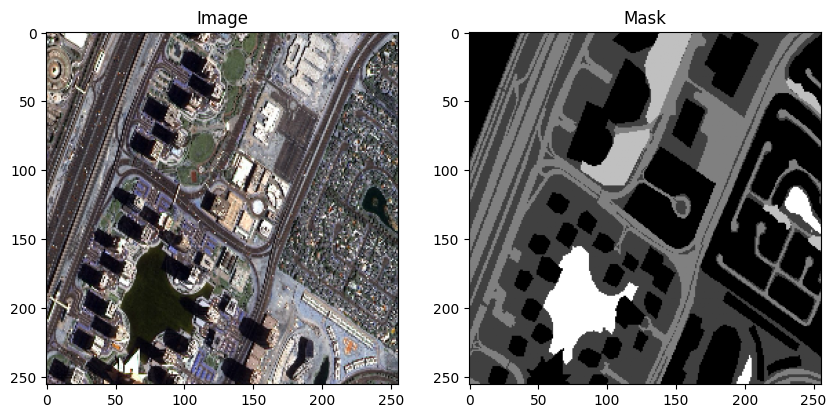

In [12]:
#数据可视化，查看数据是否对齐
import matplotlib.pyplot as plt

for img, mask in dataset.take(1):

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.title("Image")
    plt.imshow(img[0])  # batch里的第一张

    plt.subplot(1,2,2)
    plt.title("Mask")
    plt.imshow(mask[0].numpy().squeeze(), cmap='gray')

    plt.show()

In [13]:
from tensorflow.keras import layers, Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, \
    Dropout, Lambda
def unet(input_shape=(256,256,3),num_classes=6):
    inputs=layers.Input(input_shape)

    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = Dropout(0.2)(c1)
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = Dropout(0.2)(c2)
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = MaxPooling2D(pool_size=(2, 2))(c4)

    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = Dropout(0.3)(c5)
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)

    u6 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)

    u7 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)

    u8 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = Dropout(0.2)(c8)
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)

    u9 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1], axis=3)
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = Dropout(0.2)(c9)
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)
    # define output layer
    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(c9)

    model = Model(inputs,outputs)


    return model

model = unet(num_classes=6)
model.summary()
print(model.output.shape)
print(mask.dtype)
print("model output:", model.output.shape)

for img, mask in dataset.take(1):
    pred = model(img)
    print("pred shape:", pred.shape)
    print("mask shape:", mask.shape)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 256, 256,  │        448 │ input_layer_2[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 256, 256,  │          0 │ conv2d_38[0][0]   │
│ (Dropout)           │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 256, 256,  │      2,320 │ dropout_18[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 128, 128,  │          0 │ conv2d_39[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 128, 128,  │      4,640 │ max_pooling2d_8[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 128, 128,  │          0 │ conv2d_40[0][0]   │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 128, 128,  │      9,248 │ dropout_19[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 64, 64,    │          0 │ conv2d_41[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 64, 64,    │          0 │ conv2d_42[0][0]   │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 64, 64,    │     36,928 │ dropout_20[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 32, 32,    │          0 │ conv2d_43[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_10… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 32, 32,    │          0 │ conv2d_44[0][0]   │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 32, 32,    │    147,584 │ dropout_21[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 16, 16,    │          0 │ conv2d_45[0][0] 

 Total params: 1,941,190 (7.41 MB)

 Trainable params: 1,941,190 (7.41 MB)

 Non-trainable params: 0 (0.00 B)

(None, 256, 256, 6)
<dtype: 'int32'>
model output: (None, 256, 256, 6)
pred shape: (4, 256, 256, 6)
mask shape: (4, 256, 256)


Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.2006 - loss: 1.7771 - val_accuracy: 0.2825 - val_loss: 1.7254
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3051 - loss: 1.6319 - val_accuracy: 0.3619 - val_loss: 1.6195
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4421 - loss: 1.4845 - val_accuracy: 0.4645 - val_loss: 1.4165
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5473 - loss: 1.3143 - val_accuracy: 0.5298 - val_loss: 1.3047
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6132 - loss: 1.1517 - val_accuracy: 0.6266 - val_loss: 1.0864
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6257 - loss: 1.0778 - val_accuracy: 0.5808 - val_loss: 1.0771
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6328 - loss: 1.0389 - val_accuracy: 0.7035 - val_loss: 0.8364
Epoch 8/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6661 - loss: 0.9671 - val_accuracy: 0.6840 - 

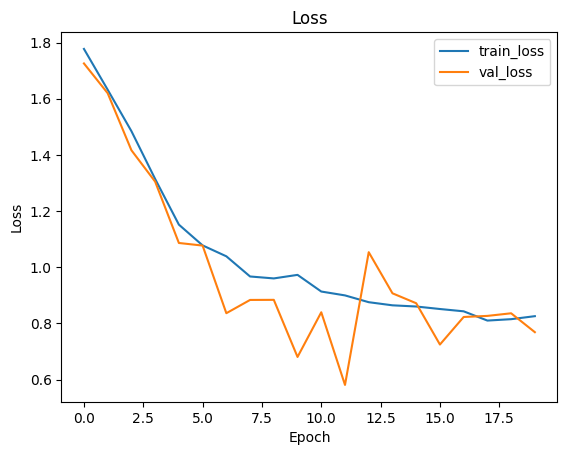

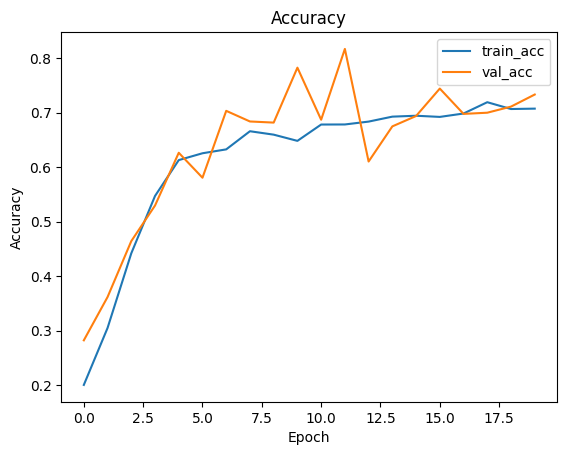

In [14]:
loss = tf.keras.losses.SparseCategoricalCrossentropy()
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[callback],
    verbose=1
)

# loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()